# Quantum Key Distribution (BB84 Protocol)

Quantum key distribution (QKD) is a method for two parties to establish a shared secret key over a public channel, where any eavesdropping attempt is detectable. The BB84 protocol, proposed by Bennett and Brassard in 1984, is the most well-known QKD protocol.

The protocol leverages a fundamental property of quantum mechanics: **measuring a quantum state disturbs it**. This means any eavesdropper (Eve) who tries to intercept the key will inevitably introduce detectable errors.

---
## QKD Step 1: Alice's Random Bits and Random Bases

Alice will start out by generating a random sequence of 0's and 1's. She will then randomly select a **basis** in which to prepare a quantum state, based on each random bit, using the table below (a table that Bob also has):

| Basis | bit = 0 | bit = 1 |
|-------|---------|--------|
| Z     | \|0⟩   | \|1⟩   |
| X     | \|+⟩   | \|−⟩   |

For example, if Alice randomly generated a **0** and randomly selected the **X basis**, then she would prepare the quantum state:

$$|\psi\rangle = |+\rangle_x = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$
 **bases**: encoding basis  `+` (rectilinear) or `×` (diagonal)
| Basis | Bit = 0 | Bit = 1 |
|-------|---------|---------|
| `+` (Rectilinear / Z) | → (H) | ↑ (V) |
| `×` (Diagonal / X)    | ↗ (D) | ↘ (A) |

One can certainly leverage quantum randomness to generate a random set of 0's and 1's, and a random basis choice. For now, let us simply assume a random set has been generated, as follows:

| | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | ... |
|---|---|---|---|---|---|---|---|---|---|---|
| **Alice's bits** | 0 | 1 | 0 | 0 | 1 | 1 | 0 | 1 | 0 | ... |
| **Alice's bases** | X | X | Z | Z | Z | X | Z | Z | X | ... |
| **Alice's states** | \|+⟩ | \|−⟩ | \|0⟩ | \|0⟩ | \|1⟩ | \|−⟩ | \|0⟩ | \|1⟩ | \|+⟩ | ... |

This set of random bits, bases, and resulting states would continue in a long sequence, to give a key of sufficient length.

---
## QKD Step 2: Bob's Random Bases

Bob also makes a random choice of bases. However, whereas Alice was using the basis choice to **prepare** her state, Bob will actually make **measurements** in these bases.

- If Bob makes a measurement in the **same basis** in which Alice prepared the state, then we can **predict** the outcome of Bob's measurement with certainty.
- When Bob happens to pick a **different basis** from the basis Alice used in preparation, we **cannot know** the outcome of Bob's measurement — it is random.

| | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | ... |
|---|---|---|---|---|---|---|---|---|---|---|
| **Alice's bits** | 0 | 1 | 0 | 0 | 1 | 1 | 0 | 1 | 0 | ... |
| **Alice's bases** | X | X | Z | Z | Z | X | Z | Z | X | ... |
| **Alice's states** | \|+⟩ | \|−⟩ | \|0⟩ | \|0⟩ | \|1⟩ | \|−⟩ | \|0⟩ | \|1⟩ | \|+⟩ | ... |
| **Bob's bases** | X | Z | X | Z | X | X | Z | X | X | ... |
| **Bob's states (a priori)** | \|+⟩ | ? | ? | \|0⟩ | ? | \|−⟩ | \|0⟩ | ? | \|+⟩ | ... |
| **Bob's states (measured)** | \|+⟩ | \|0⟩ | \|−⟩ | \|0⟩ | \|+⟩ | \|−⟩ | \|0⟩ | \|−⟩ | \|+⟩ | ... |

Consider column 0: Alice prepared \|+⟩, which is an eigenstate of X. Since Bob also randomly chose to measure in the X basis, there is only one possible outcome — \|+⟩.

In column 1, however, they chose different bases. The state Alice sent is:
$$|{-}\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$$
This has a **50% chance** of being measured by Bob in the \|0⟩ state and a **50% chance** in the \|1⟩ state. So the *a priori* row cannot be filled in for column 1. Bob will measure and obtain an eigenstate of Z.

---
## QKD Step 3: Public Discussion of Bases

Alice and Bob can now **publicly share** which basis they chose in each case. They do **not** share the actual bits or measurement results — only the basis labels.

For all the columns in which they happened to choose the **same basis**, they each know for certain what state the other had. Bob can convert the state and basis to a 0 or 1 according to the shared convention.

Rewriting the table to show **only the instances where Alice's and Bob's bases matched**:

| | 0 | 1 | 2 | 3 | 4 | ... |
|---|---|---|---|---|---|---|
| **Alice's bits** | 0 | 0 | 1 | 0 | 0 | ... |
| **Alice's bases** | X | Z | X | Z | X | ... |
| **Alice's states** | \|+⟩ | \|0⟩ | \|−⟩ | \|0⟩ | \|+⟩ | ... |
| **Bob's bases** | X | Z | X | Z | X | ... |
| **Bob's states (a priori)** | \|+⟩ | \|0⟩ | \|−⟩ | \|0⟩ | \|+⟩ | ... |
| **Bob's states (measured)** | \|+⟩ | \|0⟩ | \|−⟩ | \|0⟩ | \|+⟩ | ... |
| **Bob's bits** | 0 | 0 | 1 | 0 | 0 | ... |

Alice has successfully transmitted the bit string **00100...** to Bob. If the friends agreed ahead of time to use 5-bit strings as numbers in their one-time pad, these first five bits would give them the number:

$$4 = 0 \times 2^4 + 0 \times 2^3 + 1 \times 2^2 + 0 \times 2^1 + 0 \times 2^0$$



---
## QKD Step 4: Verify and Send Secret

Before Alice and Bob go any further, they should choose a **subset of their classical bits to compare**. Since they have only kept measurements of qubits which were prepared and measured using the same basis, all the measured values should agree.

- If there were a very small percentage that did not agree, this could be attributable to **quantum noise or hardware errors**.
- But if **many do not agree**, something has gone wrong an eavesdropper is likely present!



> **Why is intercepting the classical channel useless?**  
> Alice and Bob communicated their basis choices via classical channels  but knowing the basis used does **not** tell you what bit was sent or obtained. That is only possible if you also know Alice's starting bits, which are stored only on Alice's computer. So interception of the classical communication does **not** break the encryption.

> **What about intercepting information in the quantum channel?** See the Eavesdropping section below.

## Resistance of QKD to Eavesdropping

Eve tries to intercept Alice and Bob's quantum key. She must guess the encoding basis for each bit if wrong, she gets a random outcome with 50% probability.

| Alice's bits            | 0      | 1      | 0      | 0      | 1      | 0      | 1      | 0      | ...  |
|-------------------------|--------|--------|--------|--------|--------|--------|--------|--------|------|
| Alice's bases           | X      | X      | Z      | Z      | Z      | X      | Z      | Z      | X    |
| Alice's states          | \|+⟩   | \|−⟩   | \|0⟩   | \|0⟩   | \|1⟩   | \|−⟩   | \|0⟩   | \|1⟩   | \|+⟩ |
| Eve's guess bases       | Z      | X      | X      | Z      | X      | Z      | Z      | X      | X    |
| Eve's states (a priori) | ?      | \|−⟩   | ?      | \|0⟩   | ?      | ?      | \|0⟩   | ?      | \|+⟩ |
| Eve's states (measured) | \|1⟩   | \|−⟩   | \|+⟩   | \|0⟩   | \|−⟩   | \|0⟩   | \|0⟩   | \|−⟩   | \|+⟩ |
| Bob's bases             | X      | Z      | X      | Z      | X      | X      | Z      | X      | X    |

Since Eve doesn't know if her basis matched Alice's, she must guess what to forward to Bob — introducing errors either way.

| Alice's bits            | 0      | 1      | 0      | 0      | 1      | 0      | 1      | 0      | ...  |
|-------------------------|--------|--------|--------|--------|--------|--------|--------|--------|------|
| Alice's bases           | X      | X      | Z      | Z      | Z      | X      | Z      | Z      | X    |
| Alice's states          | \|+⟩   | \|−⟩   | \|0⟩   | \|0⟩   | \|1⟩   | \|−⟩   | \|0⟩   | \|1⟩   | \|+⟩ |
| Eve's guess bases       | Z      | X      | X      | Z      | X      | Z      | Z      | X      | X    |
| Eve's states (a priori) | ?      | \|−⟩   | ?      | \|0⟩   | ?      | ?      | \|0⟩   | ?      | \|+⟩ |
| Eve's states (measured) | \|1⟩   | \|−⟩   | \|+⟩   | \|0⟩   | \|−⟩   | \|0⟩   | \|0⟩   | \|−⟩   | \|+⟩ |
| Eve's states (sent on)  | \|1⟩   | \|0⟩   | \|+⟩   | \|0⟩   | \|−⟩   | \|0⟩   | \|0⟩   | \|−⟩   | \|0⟩ |
| Bob's bases             | X      | Z      | X      | Z      | X      | X      | Z      | X      | X    |
| Bob's states (a priori) | ?      | \|0⟩   | ?      | \|0⟩   | \|−⟩   | \|+⟩   | \|0⟩   | ?      | \|+⟩ |
| Bob's states (measured) | \|−⟩   | \|0⟩   | \|+⟩   | \|0⟩   | \|−⟩   | \|+⟩   | \|0⟩   | \|−⟩   | \|+⟩ |
| Bob's bits              | 1      | 0      | 0      | 0      | 1      | 0      | 0      | 1      | 0    |

> **Why can't Eve just copy the state?** The [no-cloning theorem](https://en.wikipedia.org/wiki/No-cloning_theorem) forbids it  no quantum operation can duplicate an arbitrary quantum state. This is a core strength of QKD.

After comparing bases, Alice and Bob keep only matching-basis bits:

| Alice's bits            | 0      | 0      | 1      | 0      | 0      | ...  |
|-------------------------|--------|--------|--------|--------|--------|------|
| Alice's bases           | X      | Z      | X      | Z      | X      | ...  |
| Alice's states          | \|+⟩   | \|0⟩   | \|−⟩   | \|0⟩   | \|+⟩   | ...  |
| Eve's guess bases       | Z      | Z      | Z      | Z      | X      | ...  |
| Eve's states (a priori) | ?      | \|0⟩   | ?      | \|0⟩   | \|+⟩   | ...  |
| Eve's states (measured) | \|1⟩   | \|0⟩   | \|0⟩   | \|0⟩   | \|+⟩   | ...  |
| Eve's states (sent on)  | \|1⟩   | \|0⟩   | \|+⟩   | \|0⟩   | \|0⟩   | ...  |
| Bob's bases             | X      | Z      | X      | Z      | X      | ...  |
| Bob's states (a priori) | ?      | \|0⟩   | \|+⟩   | \|0⟩   | \|+⟩   | ...  |
| Bob's states (measured) | \|−⟩   | \|0⟩   | \|+⟩   | \|0⟩   | \|+⟩   | ...  |
| Bob's bits              | 1      | 0      | 0      | 0      | 0      | ...  |

The bitstrings don't match Eve's interference flipped some bits. Alice and Bob can compare a portion of their bits *before* sharing the secret. A high mismatch rate reveals eavesdropping, and they abort the key exchange.

## Setup: Simulator

We use **Qiskit's `AerSimulator`** for all experiments. 



In [131]:
# Import required packages
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2

# Set up the local Aer simulator and sampler (no IBM account needed)
backend_sim = AerSimulator()           # noiseless simulation
sampler_sim = BackendSamplerV2(backend=backend_sim)

# Shared random number generator
rng = np.random.default_rng()

print("Simulator ready:", backend_sim.name)

Simulator ready: aer_simulator


---
## Experiment 1: QKD with No Eavesdropper

Let us implement the BB84 protocol in the absence of an eavesdropper using the local simulator.

Alice's bits:  [1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1.]
Alice's bases: [1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1.]
Bob's bases:   [0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1.]


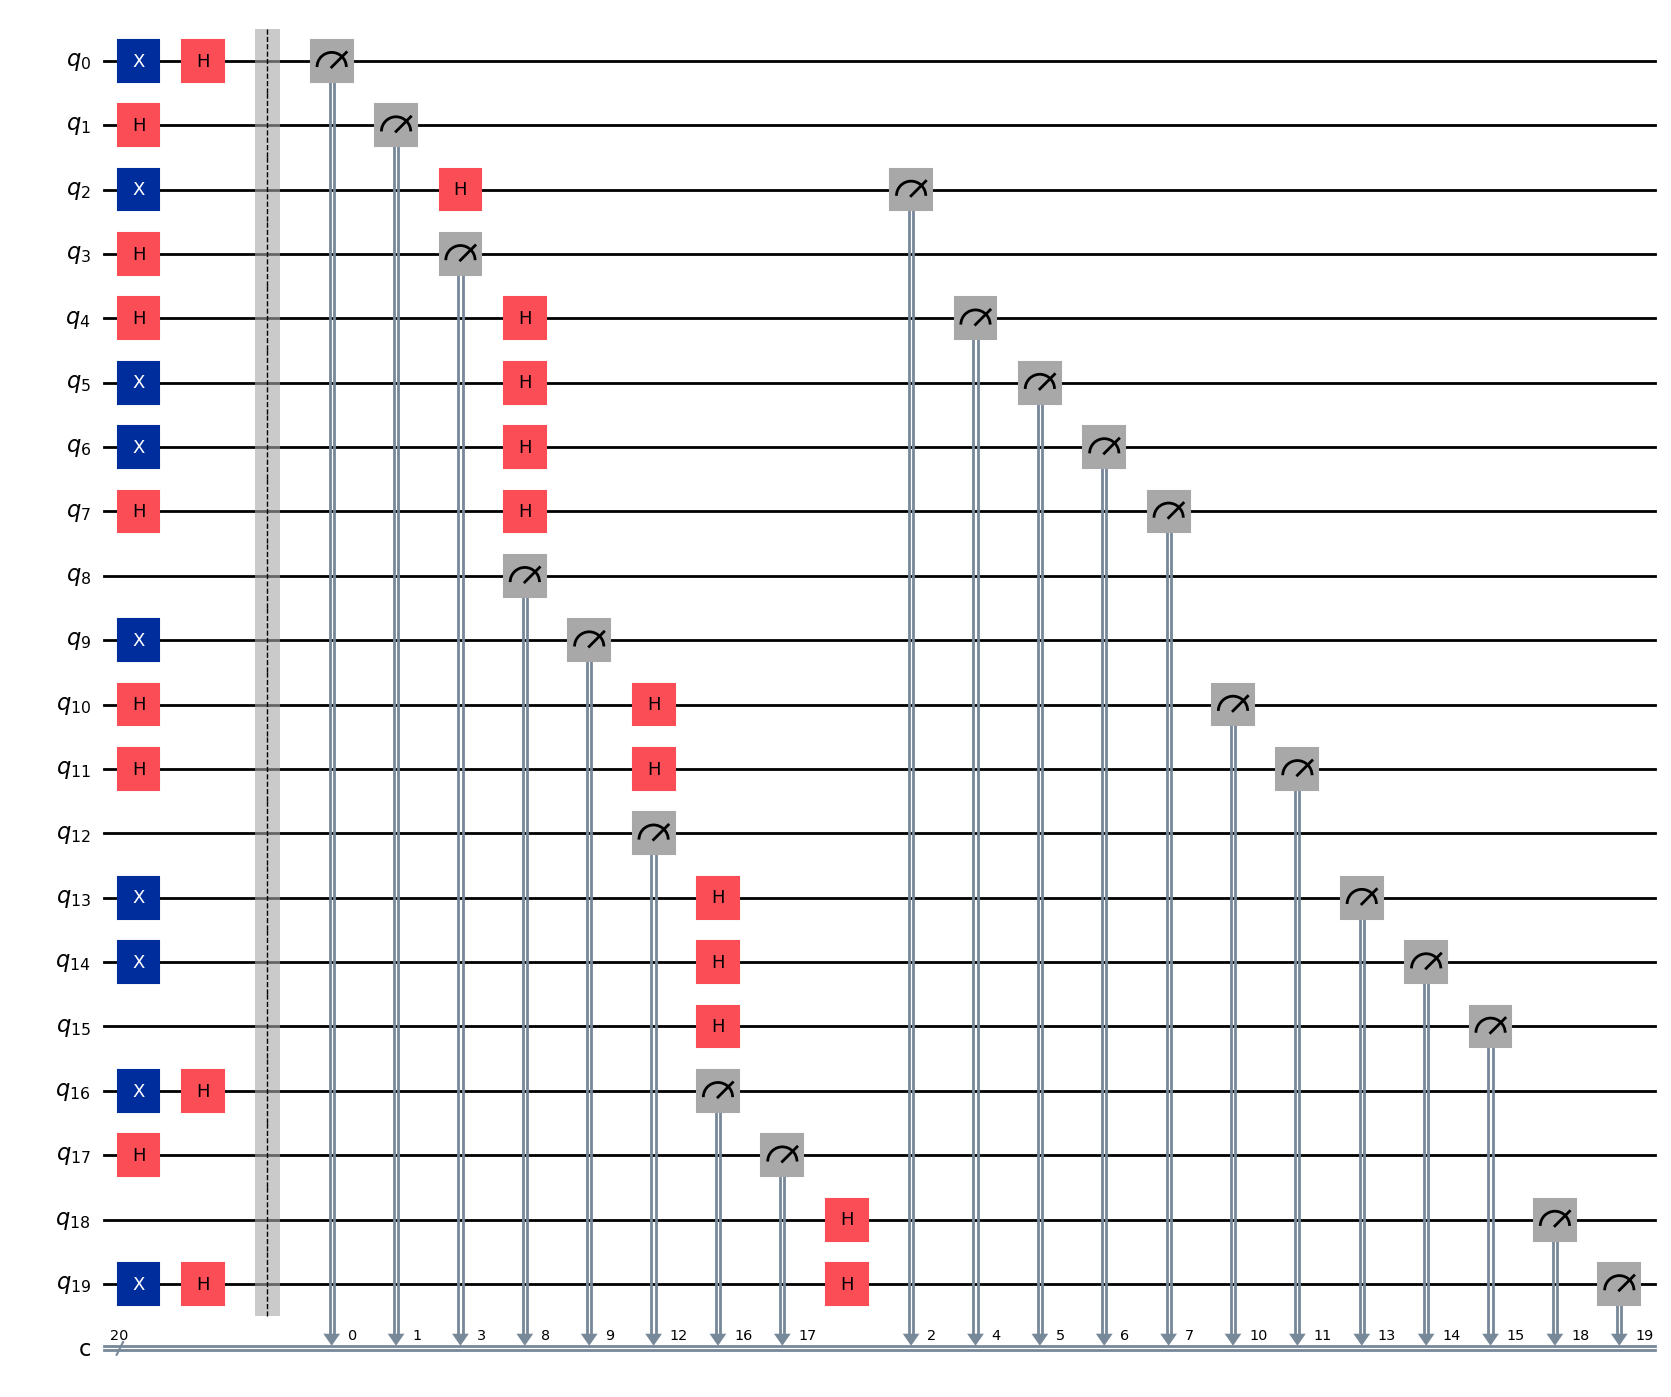

In [ ]:
# Step 1: Alice's random bits and bases, and circuit preparation 

bit_num = 20
qc = QuantumCircuit(bit_num, bit_num)

# Alice's random bits (0 or 1)
abits = np.round(rng.random(bit_num))

# Alice's random bases: 0 → Z basis, 1 → X basis
abase = np.round(rng.random(bit_num))

# Alice's state preparation
# Z basis: |0⟩ for bit=0, |1⟩ for bit=1  (X gate for |1⟩)
# X basis: |+⟩ for bit=0, |−⟩ for bit=1  (H gate, or X then H)
# note: we assign X basis is 1 and Z basis is 0
for n in range(bit_num):
    if abits[n] == 0:            # suppose alice wants to send bit 0, she has two choices: either she will choose X basis or Z basis.
        if abase[n] == 1:        # suppose she will decided to send the in X basis which we already assigned as 1 noW she will apply H gate to the qubit to preapre the state +, if she decided to send in z basis no need apply any gate. 
            qc.h(n)              # |+⟩ 0r 45 degree
    if abits[n] == 1:            #suppose alice wants to send bit 1, again she has two choices: either she will choose X basis or Z basis.
        if abase[n] == 0:        # suppose she will decided to send the in Z basis which we already assigned as 0 noW she will apply X gate to the qubit to preapre the state 1.
            qc.x(n)              # |1⟩ or 90 degree
        if abase[n] == 1:        # suppose she will decided to send the in X basis which we already assigned as 1 noW she will apply X gate and then H gate to the qubit to preapre the state -.
            qc.x(n)
            qc.h(n)              # |−⟩ or -45degree

qc.barrier()

# Step 2: Bob's random measurement bases 
bbase = np.round(rng.random(bit_num))

# Z basis: measure as-is (default in Qiskit)
# X basis: apply H before measuring to rotate to Z eigenstates
for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)

print("Alice's bits: ", abits)
print("Alice's bases:", abase)
print("Bob's bases:  ", bbase)
qc.draw("mpl")

In [134]:
# Step 3: Execute on simulator (1 shot = one run of the protocol) 
job = sampler_sim.run([qc], shots=10)
counts = job.result()[0].data.c.get_counts()

# Extract Bob's measured bits 
key = list(counts.keys())[0]
bbits = [int(b) for b in reversed(list(key))]

print("Bob's measured bits:", bbits)

Bob's measured bits: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1]


In [135]:
# Step 4: Sift key  keep only bits where bases matched 

agoodbits = []
bgoodbits = []
match_count = 0

for n in range(bit_num):
    if abase[n] == bbase[n]:                      # same basis → keep
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        if int(abits[n]) == bbits[n]:
            match_count += 1

print("Alice's sifted key:", agoodbits)
print("Bob's sifted key:  ", bgoodbits)


# QBER (Quantum Bit Error Rate): Fraction of errors in sifted bits
# Formula: QBER = (number of errors) / (number of sifted bits)
qber = 1 - (match_count / len(agoodbits)) if agoodbits else 0
# Key Rate: Fraction of bits that survived sifting (bases matched)
# Formula: Key Rate = (number of sifted bits) / (total bits sent)
key_rate = len(agoodbits) / bit_num
# Final sifted key length (bits that will form the secure key)
sifted_key_length = len(agoodbits)

print(f"\nQBER (Quantum Bit Error Rate) = {qber:.3f}")
print(f"Key Rate                      = {key_rate:.3f}")
print(f"Sifted Key Length             = {sifted_key_length} bits")

Alice's sifted key: [0, 0, 0, 1, 0, 0, 0, 1]
Bob's sifted key:   [0, 0, 0, 1, 0, 0, 0, 1]

QBER (Quantum Bit Error Rate) = 0.000
Key Rate                      = 0.400
Sifted Key Length             = 8 bits


---
## Experiment 2: QKD with an Eavesdropper

We now insert Eve between Alice and Bob. Eve intercepts Alice's qubits, measures them in randomly chosen bases, and then re-prepares and forwards her best-guess states to Bob.

**Eve's state preparation table (same encoding convention as Alice):**

| Basis | bit = 0 | bit = 1 |
|-------|---------|--------|
| Z     | \|0⟩   | \|1⟩   |
| X     | \|+⟩   | \|−⟩   |

Since Eve doesn't know which basis Alice used, she will guess wrong ~50% of the time, collapsing the qubit into the wrong state and introducing errors that Alice and Bob can detect.

Circuit 1: Alice → Eve


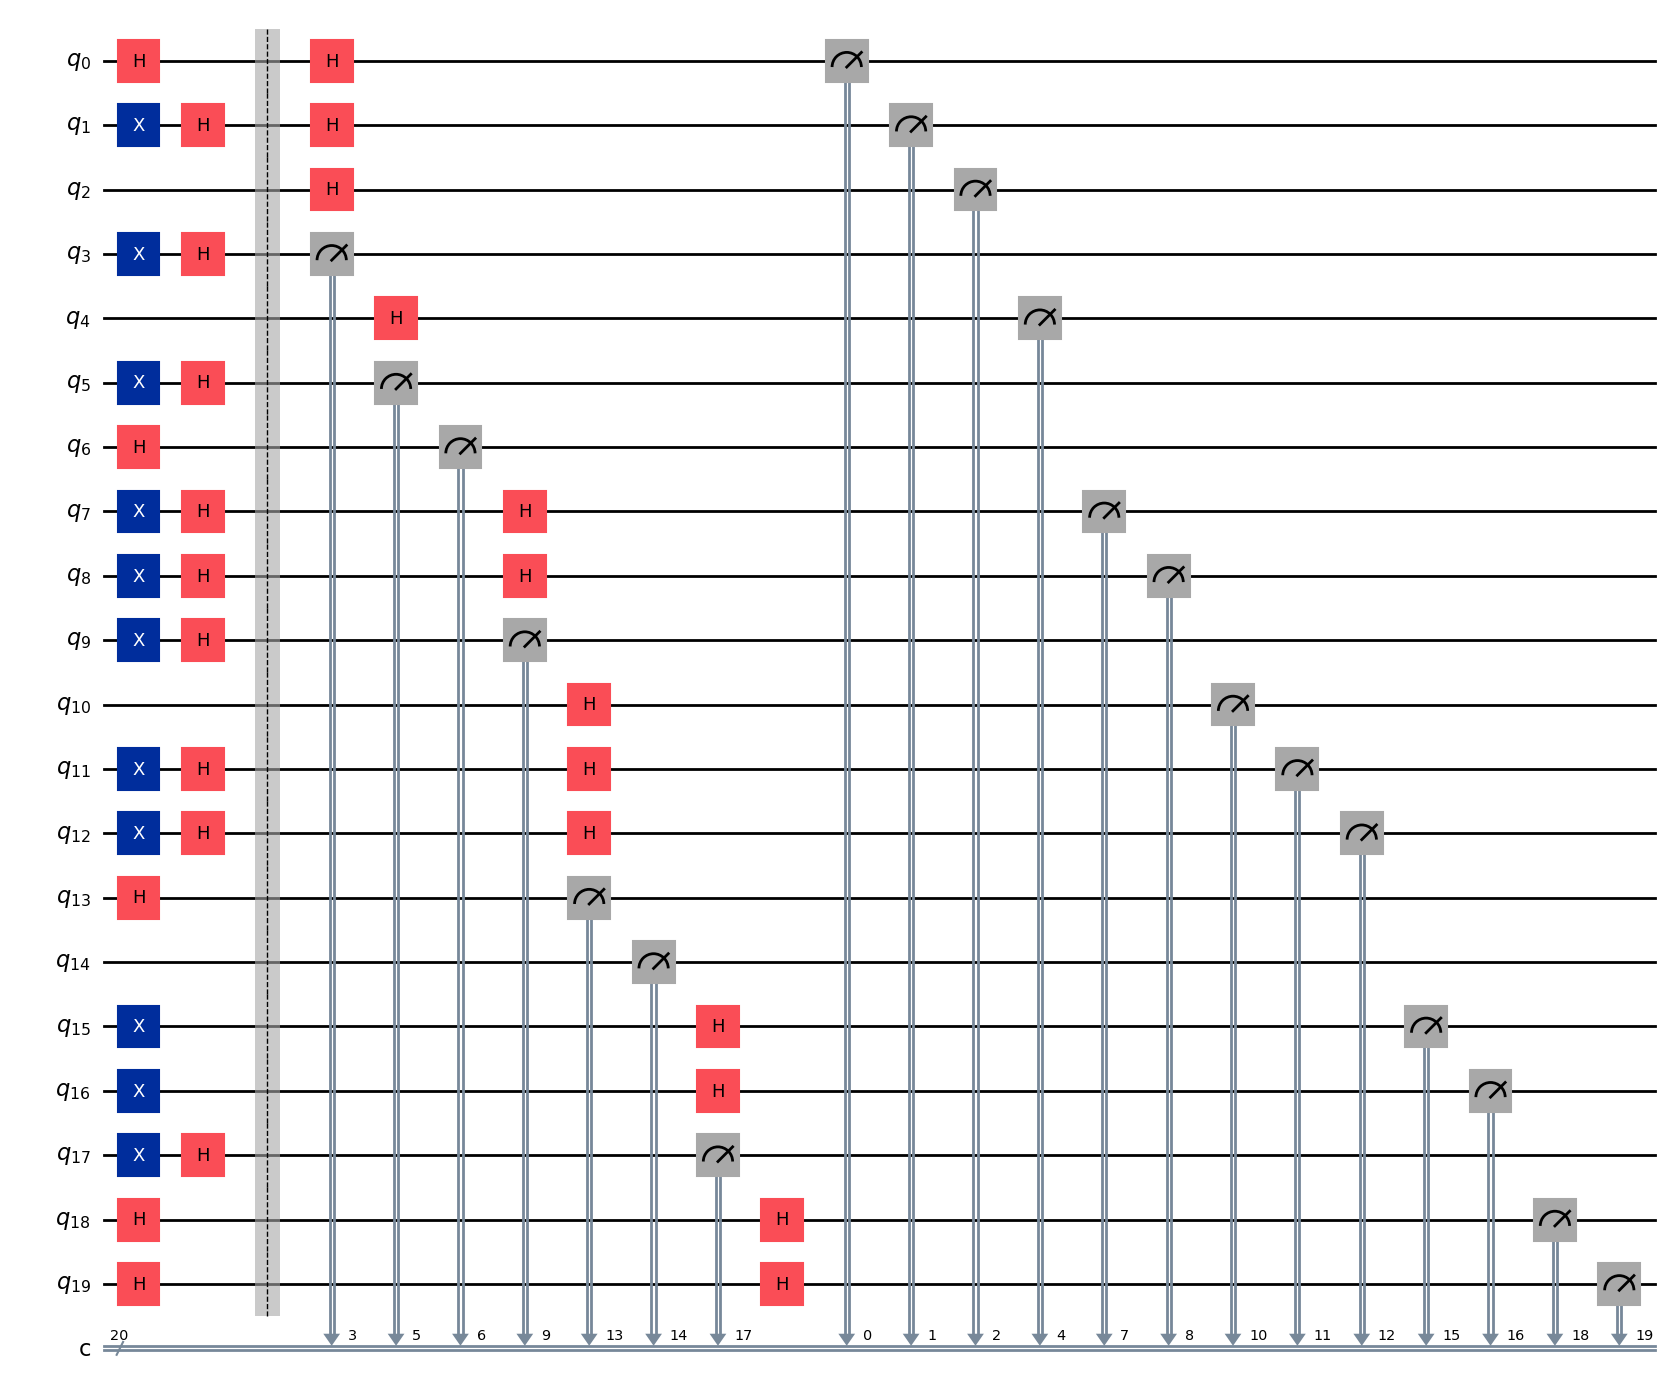

In [124]:
# Circuit 1: Alice prepares states → Eve intercepts and measures 

bit_num = 20
qr = QuantumRegister(bit_num, "q")
cr = ClassicalRegister(bit_num, "c")
qc = QuantumCircuit(qr, cr)

# Step 1: Alice's random bits and bases
abits = np.round(rng.random(bit_num))
abase = np.round(rng.random(bit_num))

# Alice's state preparation
for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# Eve's random measurement bases (she doesn't know Alice's)
ebase = np.round(rng.random(bit_num))

for m in range(bit_num):
    if ebase[m] == 1:
        qc.h(m)
    qc.measure(qr[m], cr[m])

print("Circuit 1: Alice → Eve")
qc.draw("mpl")

In [125]:
# Execute: Eve intercepts
job = sampler_sim.run([qc], shots=1)
counts = job.result()[0].data.c.get_counts()

key = list(counts.keys())[0]
ebits = [int(b) for b in reversed(list(key))]
print("Eve's measured bits:", ebits)

Eve's measured bits: [0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0]


Circuit 2: Eve → Bob


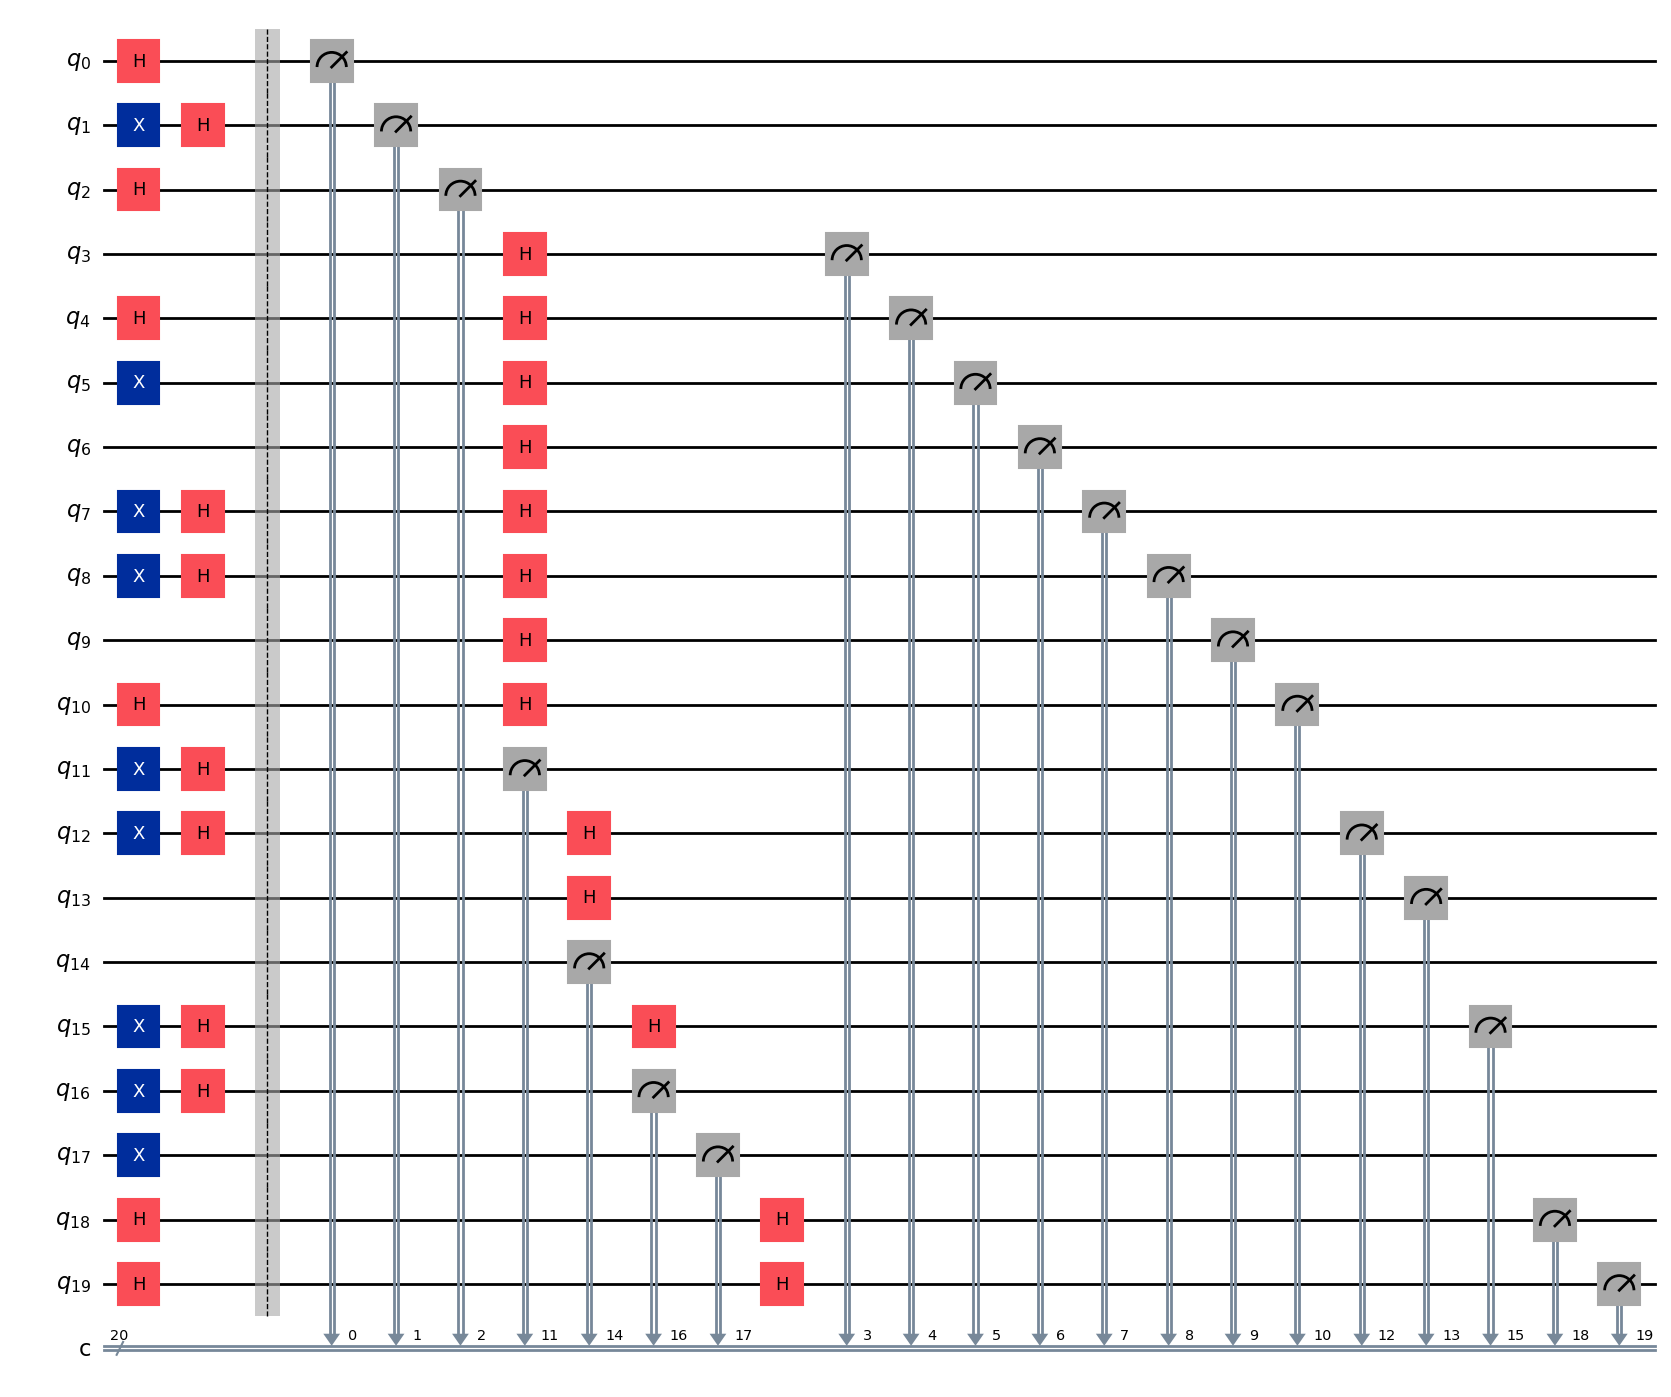

In [126]:
# Circuit 2: Eve re-prepares states → Bob measures 
# Eve assumes her basis guess was correct and re-encodes what she measured.

qr = QuantumRegister(bit_num, "q")
cr = ClassicalRegister(bit_num, "c")
qc = QuantumCircuit(qr, cr)

# Eve's state preparation (using her measured bits + her own bases)
for n in range(bit_num):
    if ebits[n] == 0:
        if ebase[n] == 1:
            qc.h(n)
    if ebits[n] == 1:
        if ebase[n] == 0:
            qc.x(n)
        if ebase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# Bob's random measurement bases
bbase = np.round(rng.random(bit_num))

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(qr[m], cr[m])

print("Circuit 2: Eve → Bob")
qc.draw("mpl")

In [127]:
# Execute: Bob receives Eve's re-prepared states
job = sampler_sim.run([qc], shots=1)
counts = job.result()[0].data.c.get_counts()

key = list(counts.keys())[0]
bbits = [int(b) for b in reversed(list(key))]
print("Bob's measured bits:", bbits)

Bob's measured bits: [1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0]


In [128]:
#  Compare Alice's and Bob's sifted keys 

agoodbits = []
bgoodbits = []
match_count = 0

for n in range(bit_num):
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        if int(abits[n]) == bbits[n]:
            match_count += 1

print("Alice's sifted key:", agoodbits)
print("Bob's sifted key:  ", bgoodbits)
# QBER (Quantum Bit Error Rate): Fraction of errors in sifted bits
# Formula: QBER = (number of errors) / (number of sifted bits)
qber = 1 - (match_count / len(agoodbits)) if agoodbits else 0
# Key Rate: Fraction of bits that survived sifting (bases matched)
# Formula: Key Rate = (number of sifted bits) / (total bits sent)
key_rate = len(agoodbits) / bit_num
# Final sifted key length (bits that will form the secure key
sifted_key_length = len(agoodbits)

print(f"\nQBER (Quantum Bit Error Rate) = {qber:.3f}")
print(f"Key Rate                      = {key_rate:.3f}")
print(f"Sifted Key Length             = {sifted_key_length} bits")
print()
if qber > 0.11:
    print("⚠  High QBER detected — eavesdropper likely present!")
else:
    print("✓  QBER within acceptable range — channel appears secure.")

Alice's sifted key: [0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]
Bob's sifted key:   [0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]

QBER (Quantum Bit Error Rate) = 0.308
Key Rate                      = 0.650
Sifted Key Length             = 13 bits

⚠  High QBER detected — eavesdropper likely present!
